In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

from plot import plot_ne_estimates
from analysis_tools import yaml_arg
from simulations import DemographicSetup
from analysis_tools import load_ibd, bin_purple, stack_purple, yaml_arg, tmrca_ne
import purple

focus_df = pd.read_csv("focus_simulations.tsv", delim_whitespace=True)
paths = focus_df.path.values.tolist()
focus_df

labels = {row["path"]: f"{row['demography']}\n{row['sample_size']}\n{row['mating']}".replace("\nnan", "") for _,row in focus_df.iterrows()}
labels

/tmp/ipykernel_3711237/3709384825.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  focus_df = pd.read_csv("focus_simulations.tsv", delim_whitespace=True)


{'2025-02-25_22-43-30.229837736': 'constant_Ne\nn=1000\nDTWF-di',
 '2025-02-25_23-13-55.999897838': 'constant_Ne100k\nn=1000\nDTWF-di',
 '2025-03-02_20-48-48.689648497': 'Quebec\nn=1000',
 '2025-03-02_21-36-34.733557857': 'constant_Ne100k\nn=10000\nDTWF-di',
 '2025-03-02_21-10-19.719367077': 'ooa2\nn=1000\nDTWF-di'}

In [2]:
i_dfs = 0
dfs = {}
for path in paths:
    path_label = labels[path]
    dfs[(path, path_label)] = []
    for i in ["filtered", "unfiltered"]:
        new_path = f"{path}/{i}_ibdne"
        for iter_n in range(1, 26):
            f = f"{new_path}/iter{iter_n}.ne"
            if os.path.exists(f):
                i_dfs += 1
                df = pd.read_csv(f, sep="\t")
                df["label"] = path_label
                df["filter"] = i
                df["iter_n"] = iter_n
                dfs[(path, path_label)].append(df)

ne_dfs = dfs

In [3]:
def get_truth(path):
    import yaml

    args = yaml.safe_load(open(path + "/args.yaml"))

    if args["custom_demo"]["object"] == None:
        return pd.DataFrame(columns=["GEN", "NE"])

    demo = DemographicSetup.create(args)

    gen_arr = np.arange(0, args["gmax"]+1)

    ne_arr = demo.debug().population_size_trajectory(gen_arr)

    return pd.DataFrame({"GEN": gen_arr, "NE": ne_arr[:,0]})

Getting custom demographic model


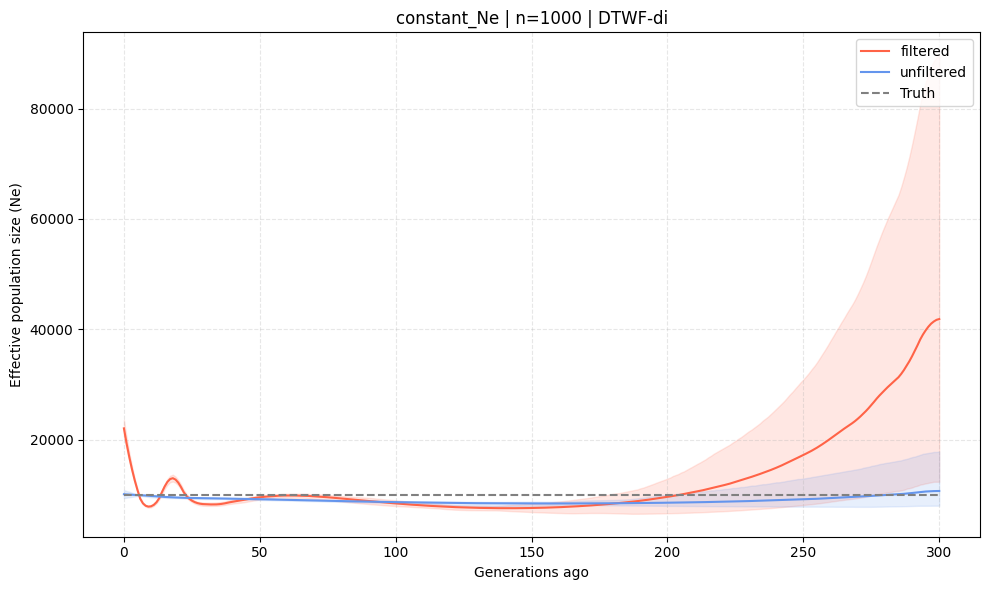

Getting custom demographic model


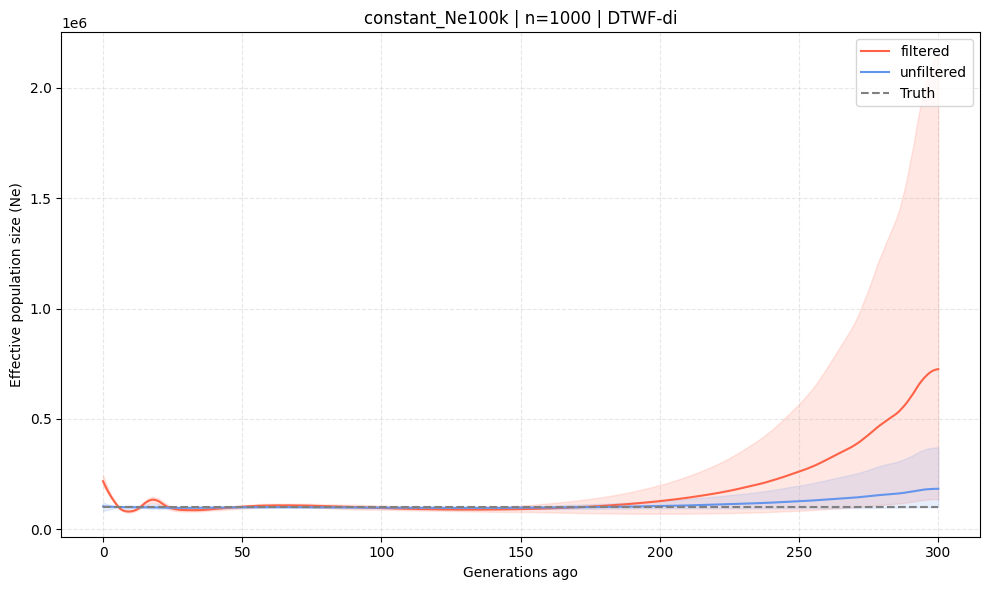

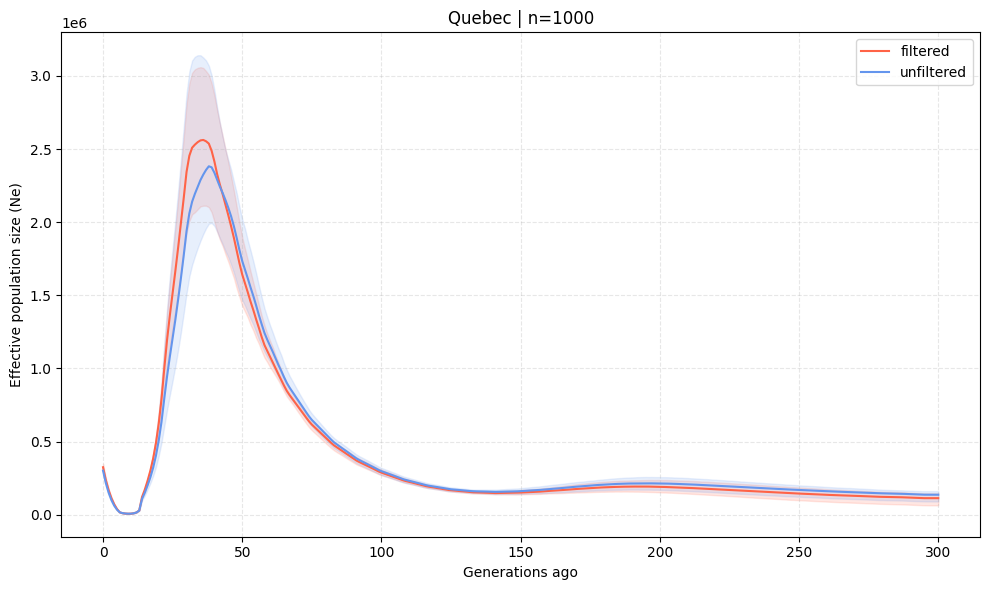

Getting custom demographic model


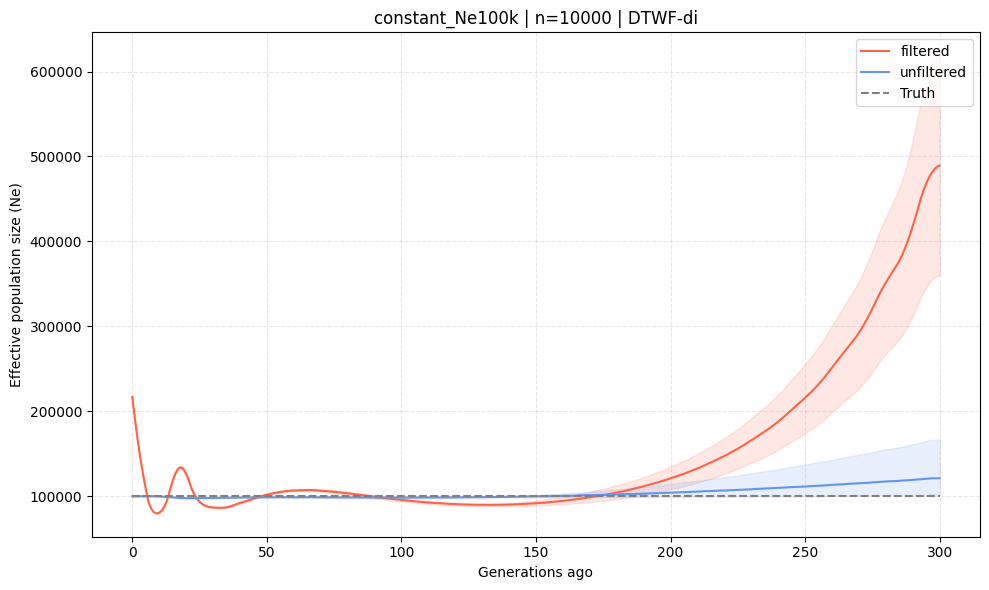

Getting custom demographic model


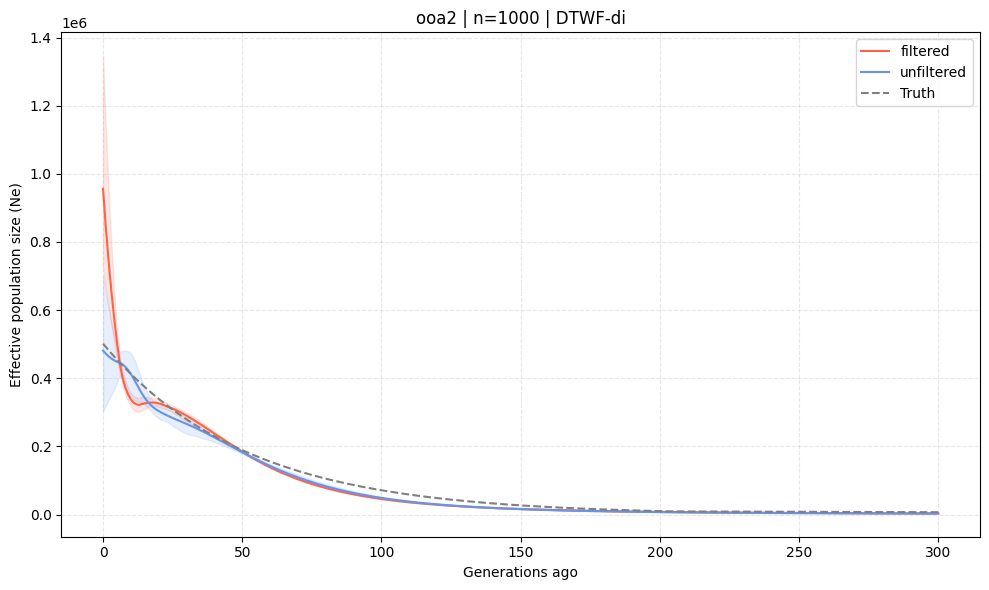

In [4]:
def plot_effective_population_size(ne_dfs, save_png=False, output_dir=None, max_gen=300):
    """
    Plot effective population size (Ne) across generations for different paths.
    
    Parameters:
    -----------
    ne_dfs : dict
        Dictionary where keys are tuples of (path, path_label) and values are lists of DataFrames.
    save_png : bool, optional
        Whether to save the plots as PNG files. Default is False.
    output_dir : str, optional
        Directory to save PNG files. If None and save_png is True, saves in the same directory as path.
        Default is None.
    
    Returns:
    --------
    None
    """
    for (path, path_label), dfs in ne_dfs.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Get truth data
        truth_df = get_truth(path)
        
        # Extract generation values and concatenate DataFrames
        X = dfs[0].GEN.values
        df = pd.concat(dfs)
        
        # Plot each filter group
        filter_colors = {"tomato": "tomato", "cornflowerblue": "cornflowerblue"}
        for (f, f_df), color in zip(df.groupby("filter"), filter_colors.values()):
            # Calculate statistics for each generation
            stats = []
            for xv in X:
                gen_data = f_df[f_df.GEN == xv]["NE"].values
                if len(gen_data) > 0:
                    mu = np.mean(gen_data)
                    q5, q95 = np.quantile(gen_data, [0.05, 0.95])
                    stats.append((xv, q5, mu, q95))
            
            if stats:
                x_vals, lower, means, upper = zip(*stats)
                
                # Plot mean line
                sns.lineplot(x=x_vals, y=means, label=f, color=color)
                
                # Plot confidence interval
                ax.fill_between(x_vals, lower, upper, color=color, alpha=0.15)
        
        # Add truth line if available
        if truth_df.shape[0] > 0:
            sns.lineplot(data=truth_df, x="GEN", y="NE", linestyle="--", color="grey", label="Truth")
        
        # Set labels and title
        clean_label = path_label.replace("\n", " | ")
        plt.title(clean_label)
        plt.xlabel("Generations ago")
        plt.ylabel("Effective population size (Ne)")
        
        # Add grid and legend
        plt.grid(alpha=0.3, linestyle='--')
        plt.legend(loc='best')

        if max_gen < 300:
            plt.xlim(0, max_gen)
        
        # Adjust layout
        plt.tight_layout()
        
        # Save figure if requested
        if save_png:
            if output_dir is None:
                output_dir = os.path.dirname(path) if os.path.dirname(path) else '.'
            
            # Create a filename-friendly version of the path_label
            filename = path_label.replace("\n", "_").replace(" ", "_")
            # Remove any special characters that might cause issues in filenames
            filename = re.sub(r'[^\w\-_]', '', filename)
            
            save_path = os.path.join(output_dir, f"{filename}.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        plt.show()

plot_effective_population_size(ne_dfs, max_gen=300)

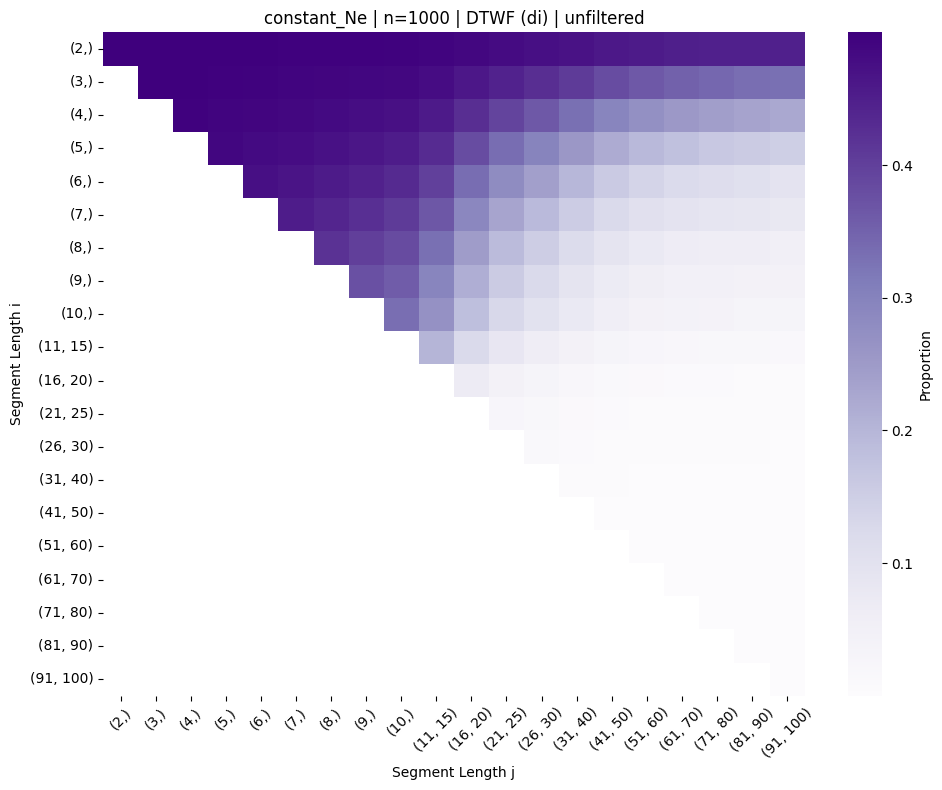

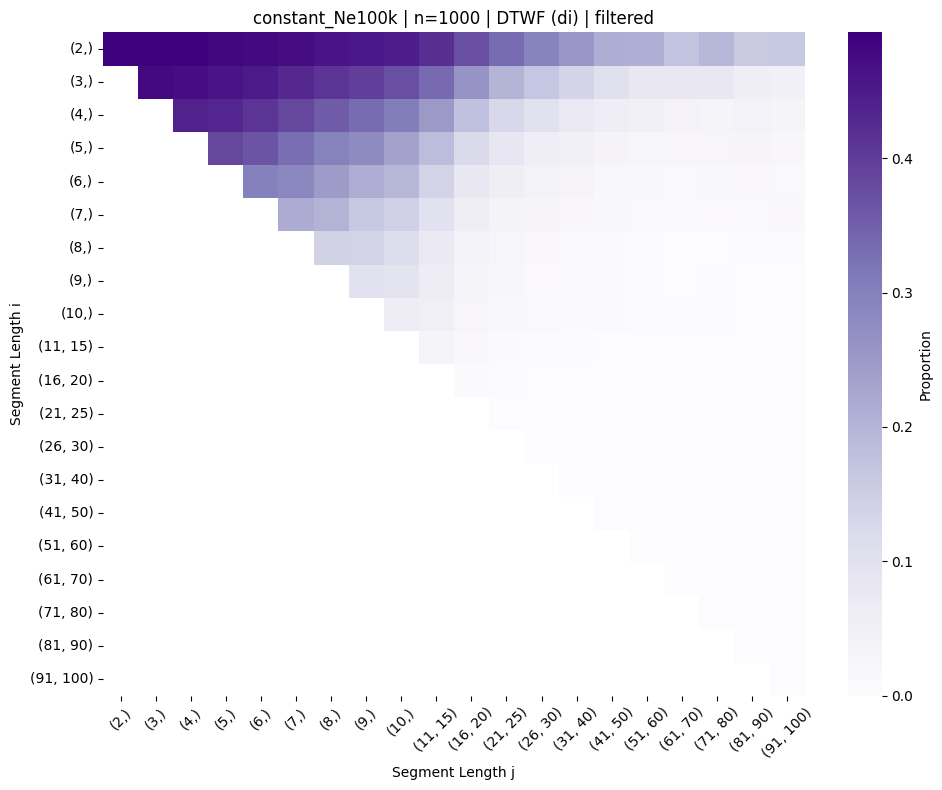

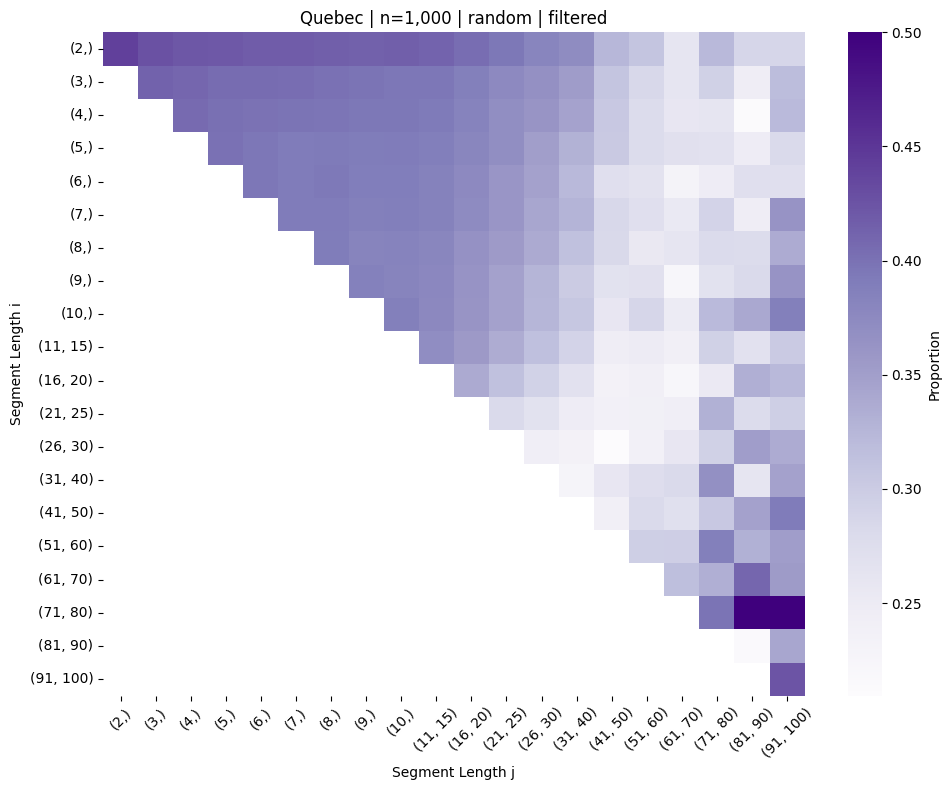

No .npy file for iteration 13


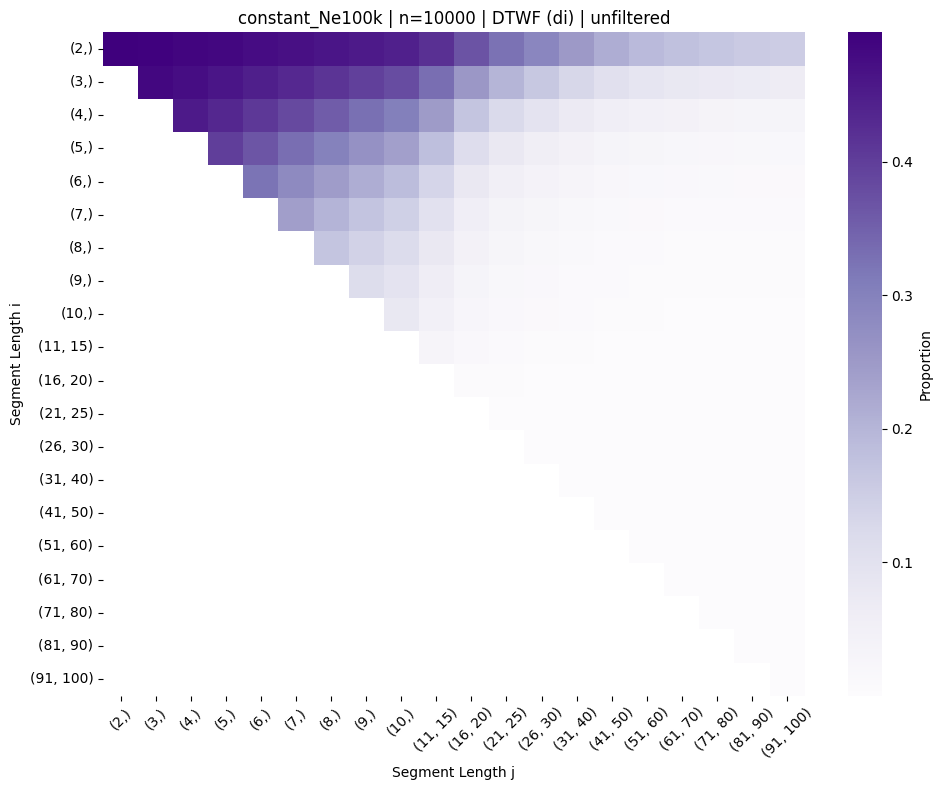

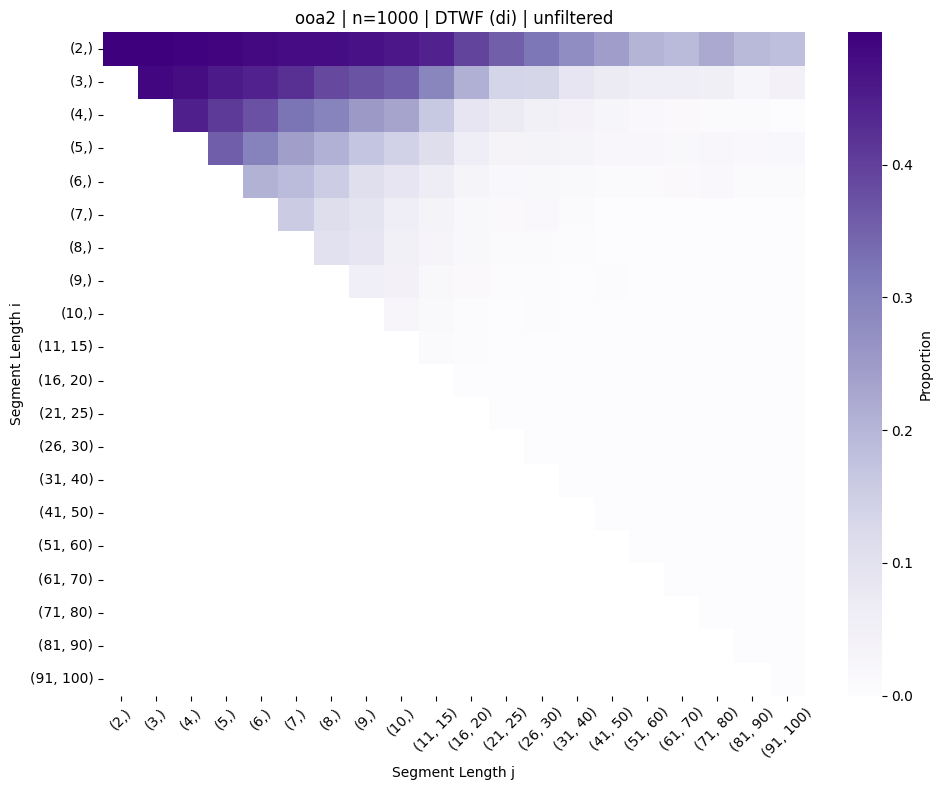

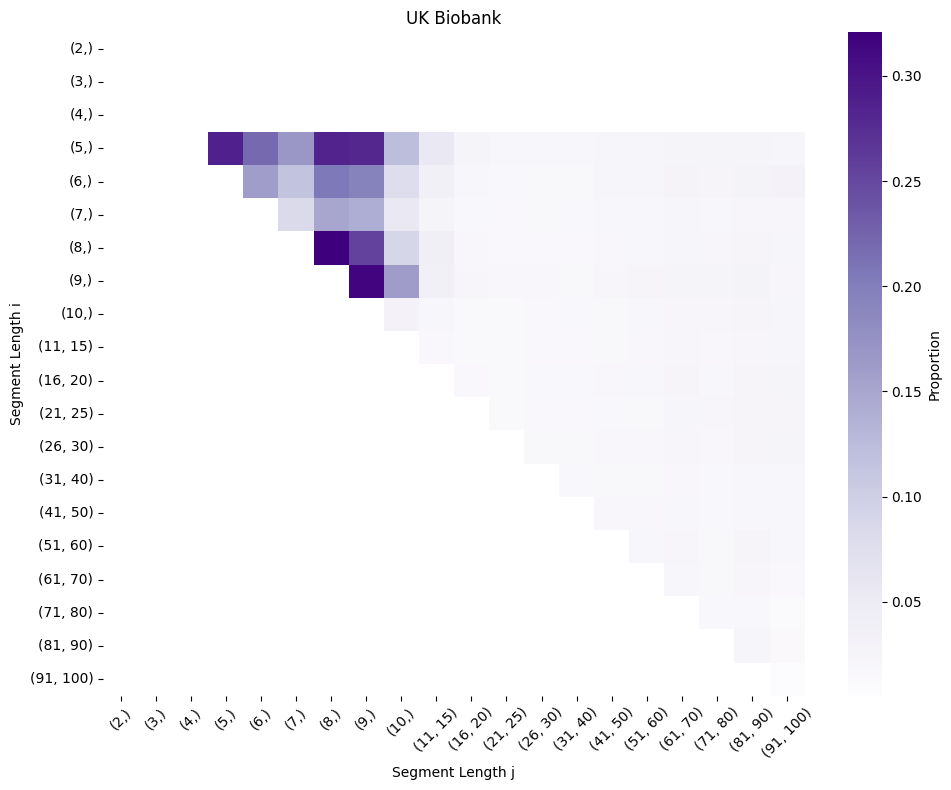

In [13]:
for path, path_label in labels.items():
    mat = stack_purple(path)
    purple.plot2(mat[0], y_labels=mat[1], x_labels=mat[1], max_out=True, label=yaml_arg(path, "label"))


mat, lab = bin_purple(np.sum(np.load("uk_biobank/iter1.npy")[:,:,:1061,:], axis=2))
purple.plot2(mat, y_labels=lab, x_labels=lab, max_out=True, label="UK Biobank")

No .npy file for iteration 13
No .npy file for iteration 18
No .npy file for iteration 19
No .npy file for iteration 20
No .npy file for iteration 21
No .npy file for iteration 22
No .npy file for iteration 23
No .npy file for iteration 24
No .npy file for iteration 25


/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-pac

<Axes: xlabel='segment', ylabel='purple_rate'>

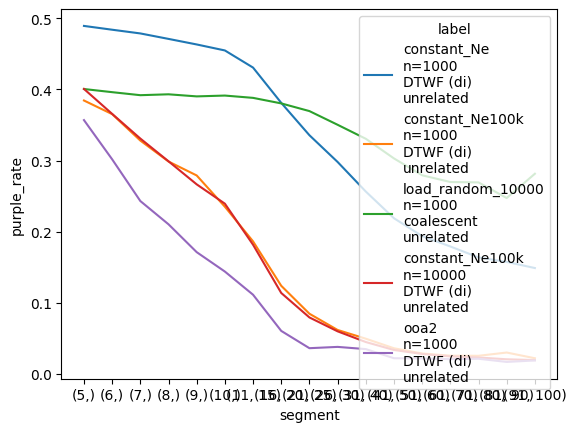

In [5]:
plot_df = []
for path in paths:
    mat, lab = stack_purple(path)
    idx = lab.index("(5,)")
    row = np.divide(mat[idx,idx:, 0], mat[idx,idx:, 1])
    tmp = pd.DataFrame({"purple_rate": row, "segment": lab[idx:], "label": yaml_arg(path, "label")})
    plot_df.append(tmp)

plot_df = pd.concat(plot_df)

sns.lineplot(data=plot_df, x="segment", y="purple_rate", hue="label")

No .npy file for iteration 13
No .npy file for iteration 18
No .npy file for iteration 19
No .npy file for iteration 20
No .npy file for iteration 21
No .npy file for iteration 22
No .npy file for iteration 23
No .npy file for iteration 24
No .npy file for iteration 25


/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-pac

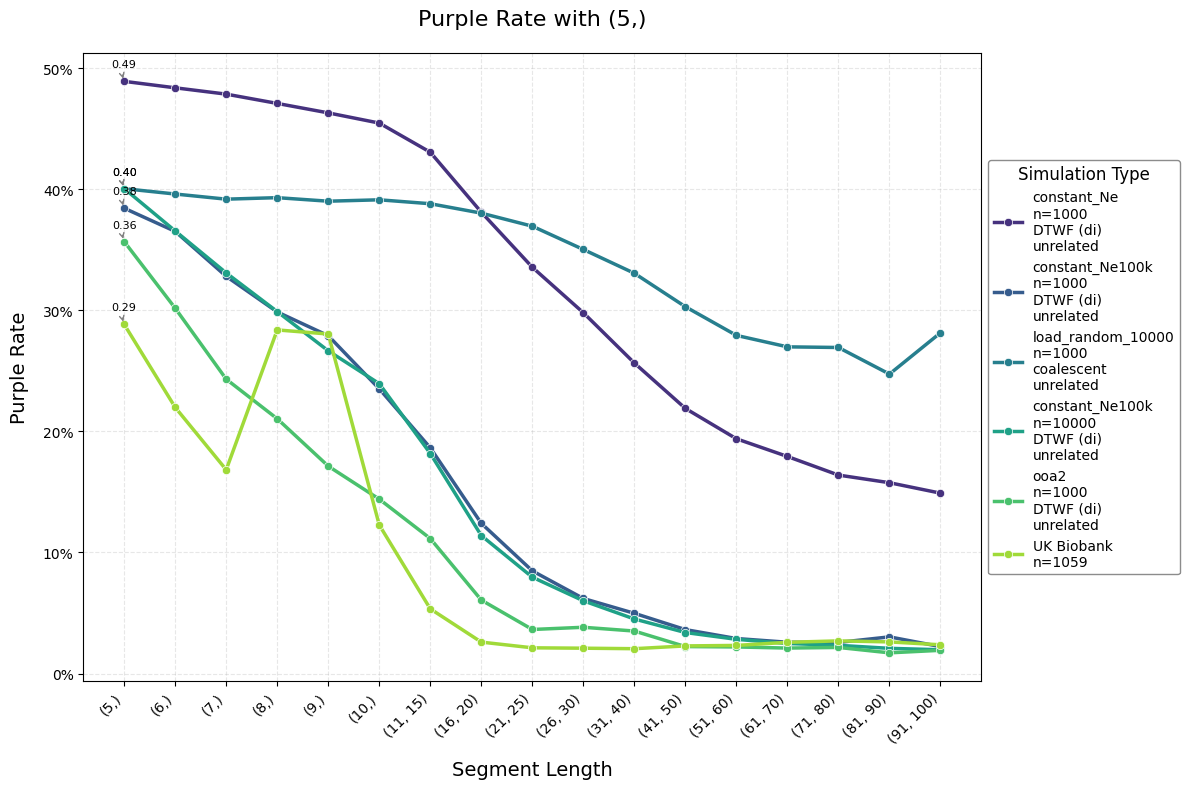

<Axes: title={'center': 'Purple Rate with (5,)'}, xlabel='Segment Length', ylabel='Purple Rate'>

In [6]:
def plot_purple_rates(paths, segment_l="(5,)", figsize=(12, 8), save_path=None):
    """
    Creates an enhanced line plot of purple rates across different segments.
    
    Parameters:
    -----------
    paths : list
        List of paths to data files
    figsize : tuple, optional
        Figure size (width, height) in inches
    save_path : str, optional
        Path to save the figure. If None, figure is displayed
    """
    plot_df = []
    for path in paths + ["uk_biobank"]:
        if path == "uk_biobank":
            mat, lab = bin_purple(np.sum(np.load("uk_biobank/iter1.npy")[:,:,:1061,:], axis=2))
        else:
            mat, lab = stack_purple(path)
        idx = lab.index(segment_l)
        row = np.divide(mat[idx, idx:, 0], mat[idx, idx:, 1])
        tmp = pd.DataFrame({
            "purple_rate": row, 
            "segment": lab[idx:], 
            "label": yaml_arg(path, "label")
        })
        plot_df.append(tmp)

    plot_df = pd.concat(plot_df)
    
    # Set up the figure
    plt.figure(figsize=figsize)
    
    # Create a custom color palette with distinct colors
    palette = sns.color_palette("viridis", len(plot_df["label"].unique()))
    
    # Create the line plot with improved styling
    ax = sns.lineplot(
        data=plot_df, 
        x="segment", 
        y="purple_rate", 
        hue="label",
        palette=palette,
        linewidth=2.5,
        marker='o',
        markersize=6,
        markeredgecolor='white',
        markeredgewidth=0.5
    )
    
    # Improve styling
    plt.grid(alpha=0.3, linestyle='--')
    
    # Set labels and title
    plt.title(f"Purple Rate with {segment_l}", fontsize=16, pad=20)
    plt.xlabel("Segment Length", fontsize=14, labelpad=10)
    plt.ylabel("Purple Rate", fontsize=14, labelpad=10)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    
    # Format y-axis to show percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Move legend outside the plot area
    plt.legend(
        title="Simulation Type",
        title_fontsize=12,
        fontsize=10,
        loc='center left', 
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    # Add annotations for maximum and minimum values
    for label in plot_df["label"].unique():
        label_data = plot_df[plot_df["label"] == label]
        max_idx = label_data["purple_rate"].idxmax()
        
        # Annotate maximum value
        plt.annotate(
            f'{label_data["purple_rate"].max():.2f}',
            xy=(label_data.loc[max_idx, "segment"], label_data.loc[max_idx, "purple_rate"]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='gray')
        )
    
    plt.tight_layout()
    
    # Save or display the figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()
        
    return ax

plot_purple_rates(paths)

Plot for 2025-02-25_22-43-30.229837736


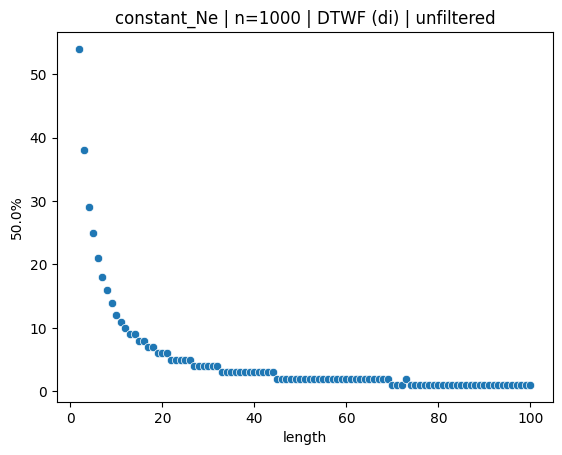

Plot for 2025-02-25_23-13-55.999897838


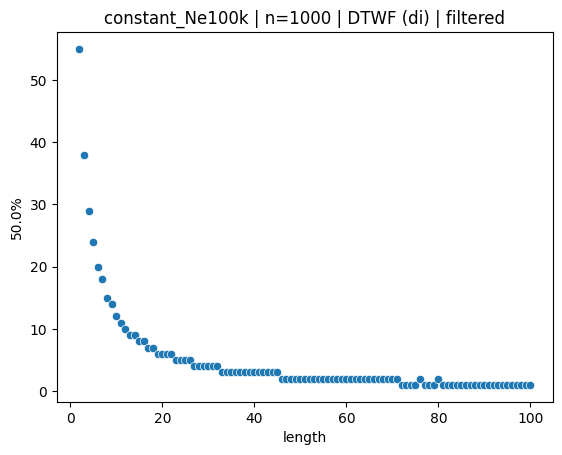

Plot for 2025-03-02_20-48-48.689648497


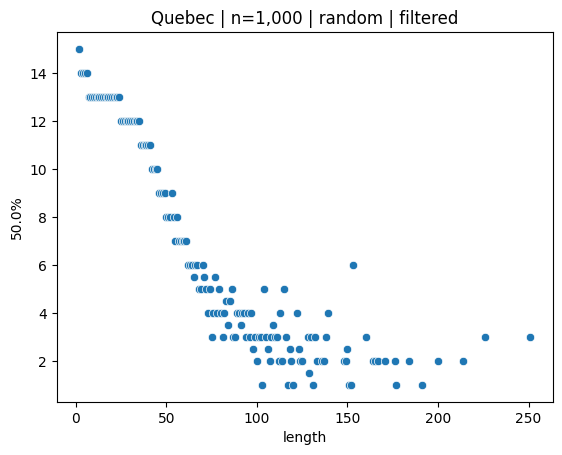

Not found: 2025-03-02_21-36-34.733557857/tmrca_by_length.csv
Plot for 2025-03-02_21-10-19.719367077


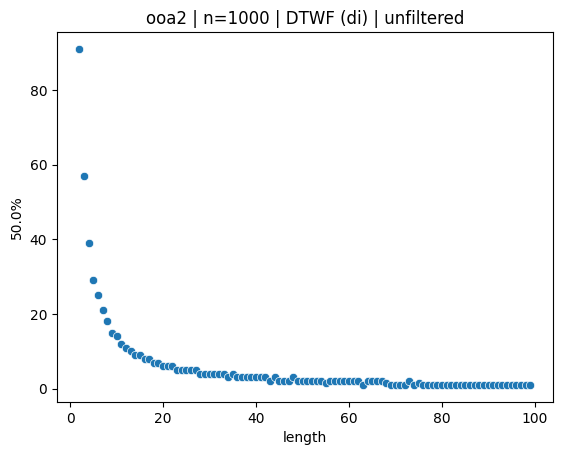

In [7]:
for path in paths:
    if not os.path.exists(f"{path}/tmrca_by_length.csv"):
        print("Not found: " + f"{path}/tmrca_by_length.csv")
        continue
    print(f"Plot for {path}")
    df = pd.read_csv(f"{path}/tmrca_by_length.csv")
    sns.scatterplot(data=df, x="length", y="50.0%")
    plt.title(yaml_arg(path, "label").replace("\n", " | "))
    plt.show()

📊 Creating plot for: constant_Ne | n=1000 | DTWF (di) | unfiltered


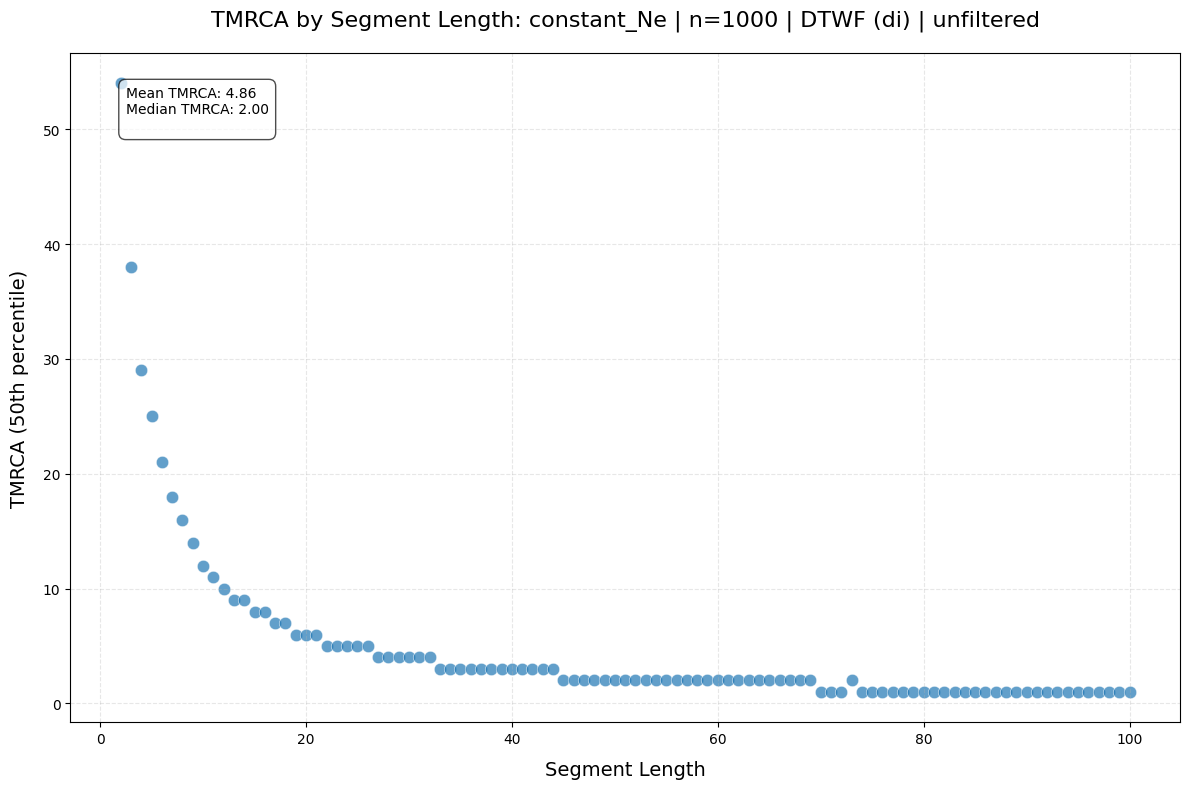

📊 Creating plot for: constant_Ne100k | n=1000 | DTWF (di) | filtered


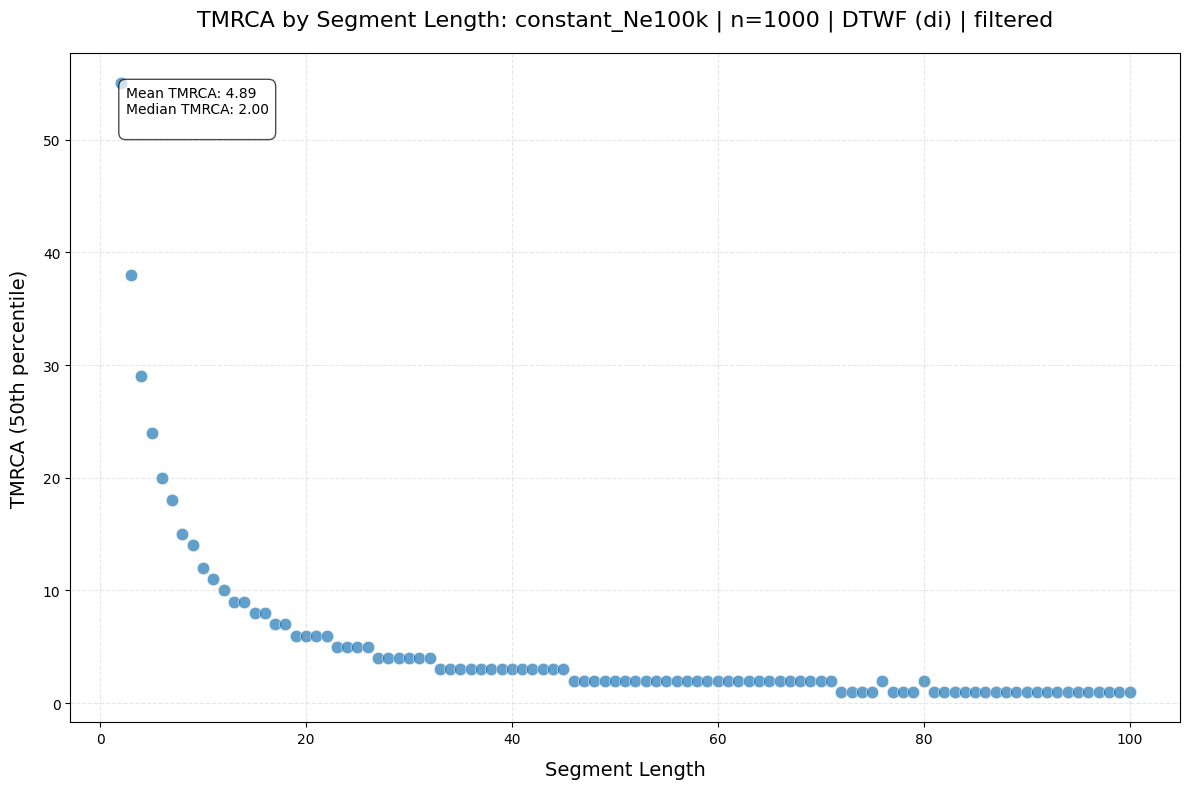

📊 Creating plot for: Quebec | n=1,000 | random | filtered


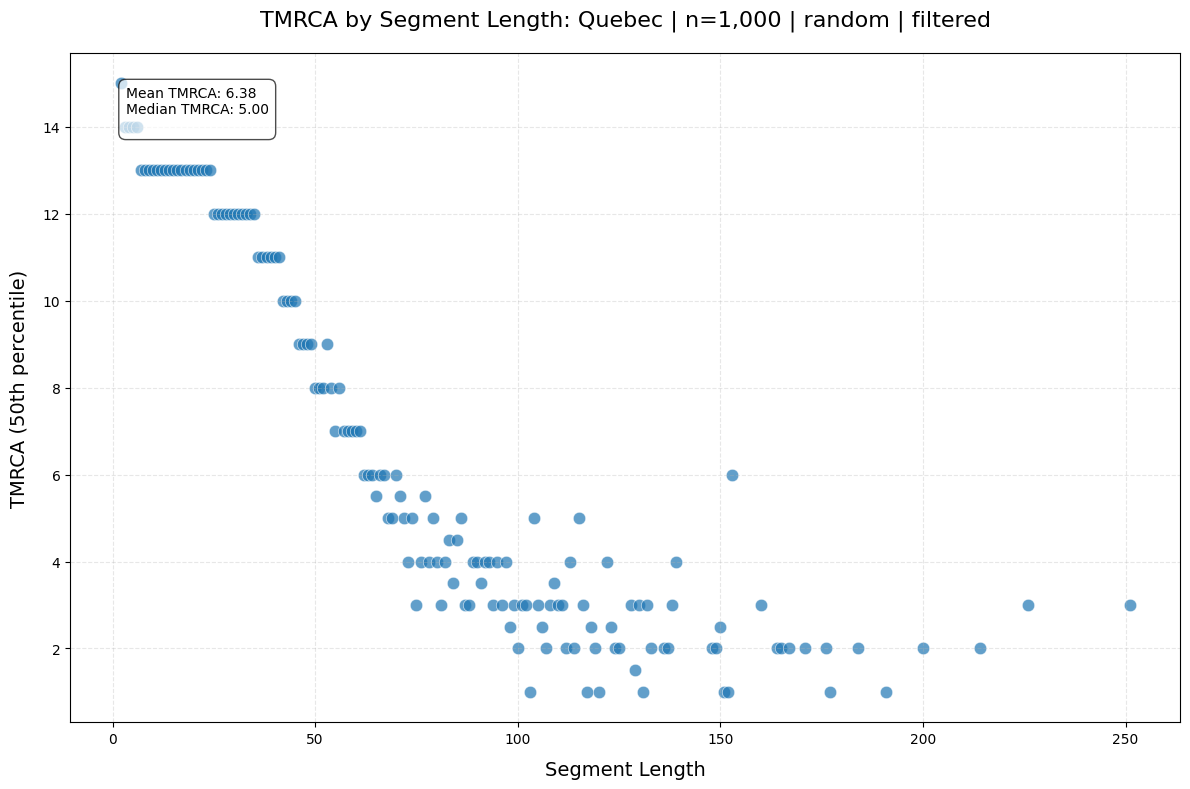

⚠️ Not found: 2025-03-02_21-36-34.733557857/tmrca_by_length.csv
📊 Creating plot for: ooa2 | n=1000 | DTWF (di) | unfiltered


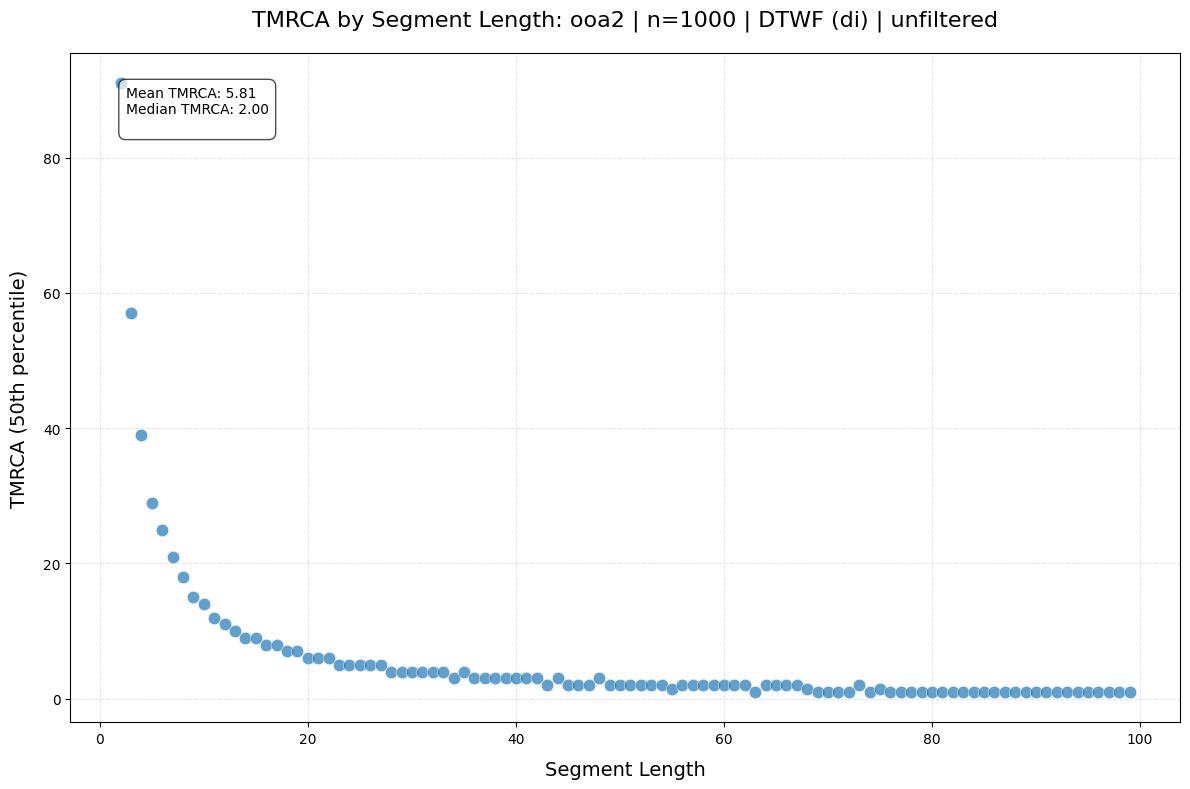

In [8]:
def plot_tmrca_by_length(paths, figsize=(12, 8), save_dir=None, plot_type='both', alpha=0.7):
    """
    Creates polished scatter plots of TMRCA by segment length for each path.
    
    Parameters:
    -----------
    paths : list
        List of paths to data directories
    figsize : tuple, optional
        Figure size (width, height) in inches
    save_dir : str, optional
        Directory to save the figures. If None, figures are displayed
    plot_type : str, optional
        Type of plot to create: 'scatter', 'line', or 'both'
    alpha : float, optional
        Transparency of scatter points
    """
    for path in paths:
        tmrca_file = f"{path}/tmrca_by_length.csv"
        
        if not os.path.exists(tmrca_file):
            print(f"⚠️ Not found: {tmrca_file}")
            continue
            
        # Read data
        df = pd.read_csv(tmrca_file)
        
        # Get path label
        label = yaml_arg(path, "label").replace("\n", " | ")
        print(f"📊 Creating plot for: {label}")
        
        # Set up the figure
        plt.figure(figsize=figsize)
        
        # Create the main plot
        if plot_type in ['scatter', 'both']:
            scatter = sns.scatterplot(
                data=df, 
                x="length", 
                y="50.0%",
                alpha=alpha,
                s=80,  # Point size
                color='#1f77b4',  # Blue color
                edgecolor='white',
                linewidth=0.5
            )
        
        # if plot_type in ['line', 'both']:
        #     # Add trend line
        #     sns.regplot(
        #         data=df, 
        #         x="length", 
        #         y="50.0%",
        #         scatter=False,
        #         line_kws={"color": "red", "alpha": 0.7, "lw": 2, "ls": "--"},
        #         ci=None
        #     )
            
        # Add confidence intervals if available
        if "25.0%" in df.columns and "75.0%" in df.columns:
            plt.fill_between(
                df["length"], 
                df["25.0%"], 
                df["75.0%"],
                alpha=0.2,
                color='skyblue',
                label='IQR (25%-75%)'
            )
        
        # Improve styling
        plt.grid(alpha=0.3, linestyle='--')
        
        # Set labels and title
        plt.title(f"TMRCA by Segment Length: {label}", fontsize=16, pad=20)
        plt.xlabel("Segment Length", fontsize=14, labelpad=10)
        plt.ylabel("TMRCA (50th percentile)", fontsize=14, labelpad=10)
        
        # Add summary statistics as text
        stats_text = (
            f"Mean TMRCA: {df['50.0%'].mean():.2f}\n"
            f"Median TMRCA: {df['50.0%'].median():.2f}\n"
        )
        
        plt.annotate(
            stats_text,
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            va='top',
            ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7)
        )
        
        # Add legend if we have confidence intervals
        if "25.0%" in df.columns and "75.0%" in df.columns:
            plt.legend()
            
        plt.tight_layout()
        
        # Save or display the figure
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            clean_label = "".join(c if c.isalnum() else "_" for c in label)
            plt.savefig(f"{save_dir}/tmrca_{clean_label}.png", dpi=300, bbox_inches='tight')
            print(f"💾 Saved to {save_dir}/tmrca_{clean_label}.png")
        else:
            plt.show()
        
        plt.close()

plot_tmrca_by_length(paths)

📊 Processing data for: constant_Ne | n=1000 | DTWF (di) | unfiltered
📊 Processing data for: constant_Ne100k | n=1000 | DTWF (di) | filtered
📊 Processing data for: Quebec | n=1,000 | random | filtered
⚠️ Not found: 2025-03-02_21-36-34.733557857/tmrca_by_length.csv
📊 Processing data for: ooa2 | n=1000 | DTWF (di) | unfiltered


/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-pac

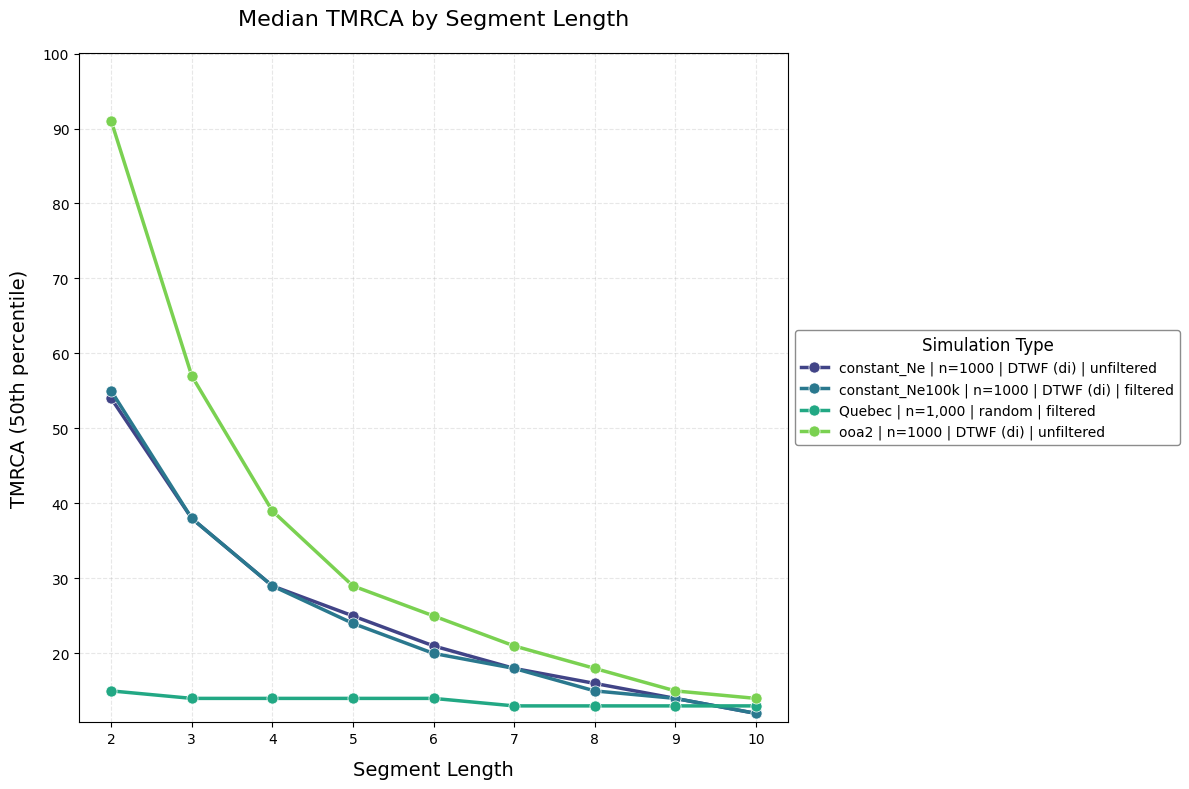

<Axes: title={'center': 'Median TMRCA by Segment Length'}, xlabel='Segment Length', ylabel='TMRCA (50th percentile)'>

In [15]:
def plot_tmrca_lineplot(paths, min_length=2, max_length=10, figsize=(12, 8), save_path=None):
    """
    Creates a line plot of median TMRCA values for multiple simulations,
    styled consistently with the purple node plots.
    
    Parameters:
    -----------
    paths : list
        List of paths to data directories
    min_length : int, optional
        Minimum segment length to include (inclusive)
    max_length : int, optional
        Maximum segment length to include (inclusive)
    figsize : tuple, optional
        Figure size (width, height) in inches
    save_path : str, optional
        Path to save the figure. If None, figure is displayed
    """
    # Initialize a list to hold all data
    all_data = []
    
    # Process each path
    for path in paths:
        tmrca_file = f"{path}/tmrca_by_length.csv"
        
        if not os.path.exists(tmrca_file):
            print(f"⚠️ Not found: {tmrca_file}")
            continue
            
        # Read data
        df = pd.read_csv(tmrca_file)
        
        # Filter data for the specified length range
        filtered_df = df[(df['length'] >= min_length) & (df['length'] <= max_length)]
        
        if filtered_df.empty:
            print(f"⚠️ No data in the specified length range for {path}")
            continue
        
        # Get path label
        label = yaml_arg(path, "label").replace("\n", " | ")
        print(f"📊 Processing data for: {label}")
        
        # Extract median TMRCA values and add to combined dataset
        for _, row in filtered_df.iterrows():
            all_data.append({
                'length': row['length'],
                'tmrca': row['50.0%'],
                'simulation': label
            })
    
    # Convert to DataFrame
    combined_df = pd.DataFrame(all_data)
    
    if combined_df.empty:
        print("❌ No data to plot!")
        return None
    
    # Create the figure
    plt.figure(figsize=figsize)
    
    # Create the line plot with markers
    ax = sns.lineplot(
        data=combined_df,
        x='length',
        y='tmrca',
        hue='simulation',
        palette='viridis',
        linewidth=2.5,
        marker='o',
        markersize=8,
        markeredgecolor='white',
        markeredgewidth=0.5
    )
    
    # Add confidence interval bands if available
    for path in paths:
        tmrca_file = f"{path}/tmrca_by_length.csv"
        if not os.path.exists(tmrca_file):
            continue
            
        df = pd.read_csv(tmrca_file)
        filtered_df = df[(df['length'] >= min_length) & (df['length'] <= max_length)]
        
        if filtered_df.empty or "25.0%" not in df.columns or "75.0%" not in df.columns:
            continue
            
        label = yaml_arg(path, "label").replace("\n", " | ")
        color = next(c for c in ax.get_lines() if c.get_label() == label).get_color()
        
        plt.fill_between(
            filtered_df["length"], 
            filtered_df["25.0%"], 
            filtered_df["75.0%"],
            alpha=0.15,
            color=color
        )
    
    # Improve styling
    plt.grid(alpha=0.3, linestyle='--')
    
    # Set labels and title
    plt.title("Median TMRCA by Segment Length", fontsize=16, pad=20)
    plt.xlabel("Segment Length", fontsize=14, labelpad=10)
    plt.ylabel("TMRCA (50th percentile)", fontsize=14, labelpad=10)
    
    # Format legend
    plt.legend(
        title="Simulation Type",
        title_fontsize=12,
        fontsize=10,
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        framealpha=0.9,
        edgecolor='gray'
    )
    
    # Ensure x-axis shows integer values
    lengths = sorted(combined_df['length'].unique())
    plt.xticks(lengths, fontsize=10)
    plt.yticks(fontsize=10)
    
    # Set reasonable y-axis limits
    y_min = combined_df['tmrca'].min() * 0.9
    y_max = combined_df['tmrca'].max() * 1.1
    plt.ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save or display the figure
    if save_path:
        directory = os.path.dirname(save_path)
        if directory:
            os.makedirs(directory, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Saved to {save_path}")
    else:
        plt.show()
    
    plt.close()
    
    return ax

plot_tmrca_lineplot(paths)

In [32]:
def load_ibd_by_pair(path, iter_n):

    ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)

    pairs = {}
    for pair, pair_df in ibd_df.groupby([0, 2]):
        if pair_df[7].sum() < 100:
            continue
        pairs[pair] = (pair_df[7].sum(), pair_df)

    return pairs

def degree(k):
    for i, t in enumerate([-0.5, -1.5, -2.5, -3.5, -4.5]):
        if 2**(t-1) <= (k/2) < 2**t:
            return i + 1


def ne_tmrca_dataframe(path, iter_n, max_g=100):

    demo = yaml_arg(path, ("custom_demo", "object"))

    tmrca_df = tmrca_ne(demo)

    tmrca_dict = {row["length"]: row["gen"] for _,row in tmrca_df.iterrows()}

    pair_dict = load_ibd_by_pair(path, iter_n)

    dfs = []
    for pair, (tot, pair_df) in pair_dict.items():
        pair_df["tmrca"] = pair_df[7].apply(lambda x: tmrca_dict[int(x)])
        pair_df["degree"] = degree(tot / 3000)
        dfs.append(pair_df)

    print(iter_n)

    return pd.concat(dfs)


tmrca_df = pd.concat([ne_tmrca_dataframe("2025-02-27_21-27-56.774301337", i) for i in range(1, 26)])

# load_ibd_by_pair("2025-02-27_21-27-56.774301337", 1)


/tmp/ipykernel_3654705/3693752370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)


1


/tmp/ipykernel_3654705/3693752370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)


2


/tmp/ipykernel_3654705/3693752370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)


...

23


/tmp/ipykernel_3654705/3693752370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)


24


/tmp/ipykernel_3654705/3693752370.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", header=None, delim_whitespace=True)


25


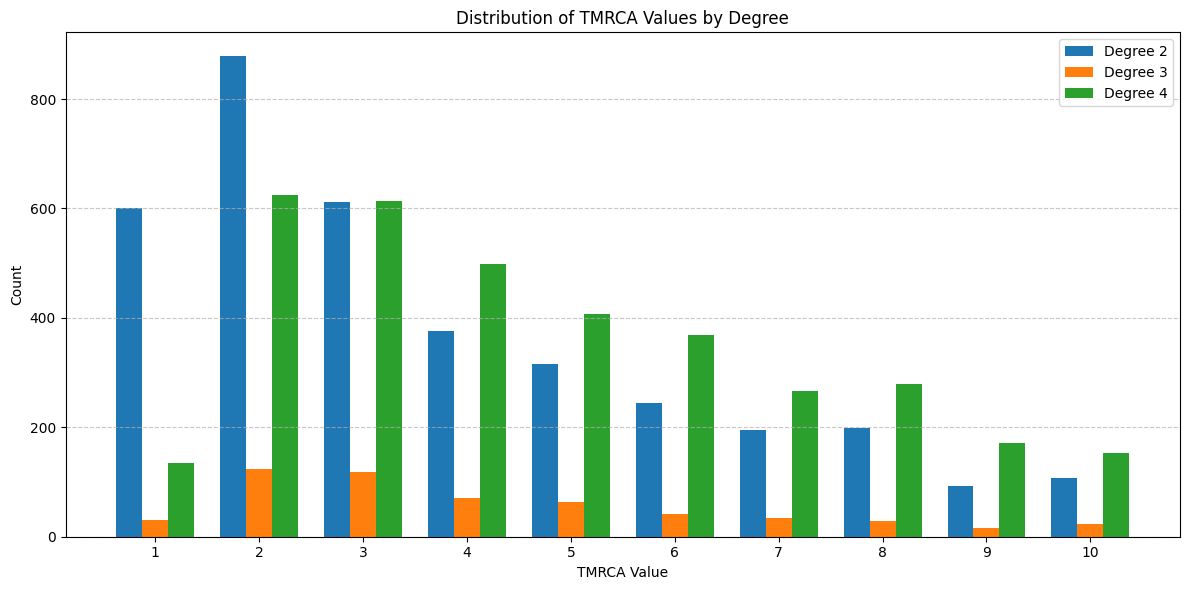

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's assume your dataframe is stored in a variable called 'df'
# First, filter for only the degrees we care about and TMRCA values <= 10
df = tmrca_df
filtered_df = df[(df['degree'].isin([2, 3, 4])) & (df['tmrca'] <= 10)]

# Group by degree and tmrca, then count occurrences
grouped = filtered_df.groupby(['degree', 'tmrca']).size().reset_index(name='count')

# Create a pivot table for easier plotting
pivot_df = grouped.pivot(index='tmrca', columns='degree', values='count').fillna(0)

# Get the unique TMRCA values for plotting
tmrca_values = sorted(filtered_df['tmrca'].unique())

# Set up the plot
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = np.arange(len(tmrca_values))

# Plot bars for each degree
for i, degree in enumerate([2, 3, 4]):
    if degree in pivot_df.columns:
        counts = [pivot_df.loc[tmrca, degree] if tmrca in pivot_df.index else 0 for tmrca in tmrca_values]
        plt.bar(index + i*bar_width, counts, bar_width, label=f'Degree {degree}')
    else:
        # Handle case where a degree might not be present in the data
        plt.bar(index + i*bar_width, [0]*len(tmrca_values), bar_width, label=f'Degree {degree}')

# Customize the plot
plt.xlabel('TMRCA Value')
plt.ylabel('Count')
plt.title('Distribution of TMRCA Values by Degree')
plt.xticks(index + bar_width, tmrca_values)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Make sure the layout looks good
plt.tight_layout()
plt.show()

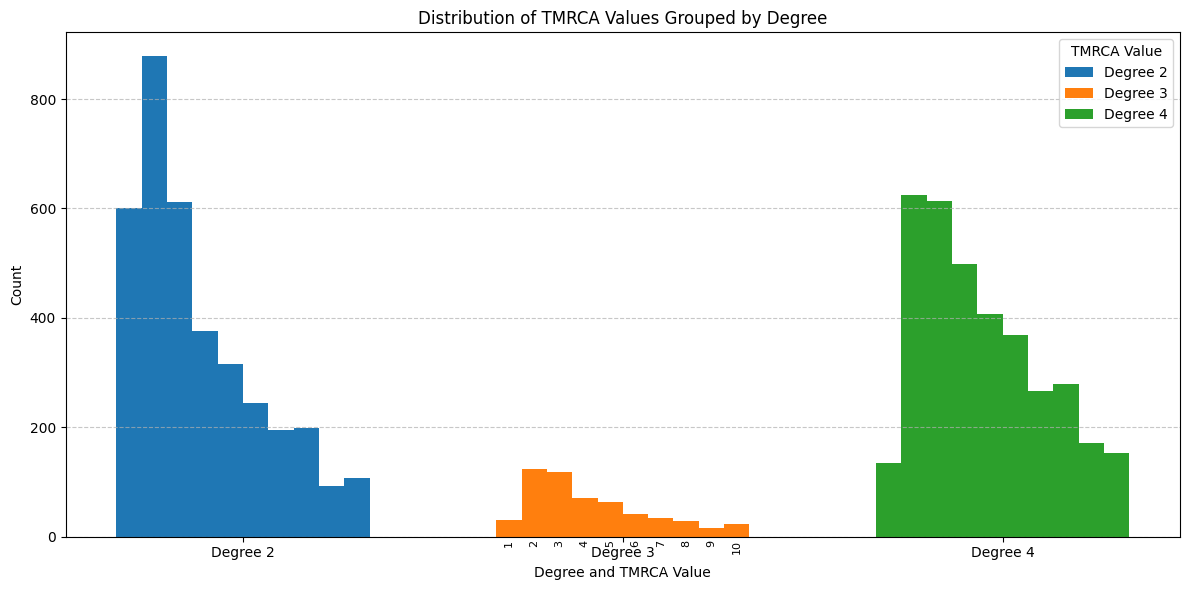

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's assume your dataframe is stored in a variable called 'df'
# First, filter for only the degrees we care about and TMRCA values <= 10
df = tmrca_df
filtered_df = df[(df['degree'].isin([2, 3, 4])) & (df['tmrca'] <= 10)]

# Group by degree and tmrca, then count occurrences
grouped = filtered_df.groupby(['degree', 'tmrca']).size().reset_index(name='count')

# Get unique degrees and TMRCA values
degrees = [2, 3, 4]  # The degrees we're interested in
tmrca_values = sorted([t for t in filtered_df['tmrca'].unique() if t <= 10])

# Set up the plot
plt.figure(figsize=(12, 6))

# Calculate the width of each group and each bar
n_degrees = len(degrees)
n_tmrca = len(tmrca_values)
group_width = 0.8  # Width of each degree group (out of 1)
bar_width = group_width / n_tmrca  # Width of each TMRCA bar
gap_between_groups = 0.2  # Gap between degree groups

# Create a dictionary for easier data lookup
count_dict = {}
for _, row in grouped.iterrows():
    count_dict[(row['degree'], row['tmrca'])] = row['count']

# Plot bars for each degree
for i, degree in enumerate(degrees):
    group_position = i * (1 + gap_between_groups)  # Position of this degree group
    
    # Create bar positions for this degree
    bar_positions = [group_position + j * bar_width for j in range(n_tmrca)]
    
    # Get counts for each TMRCA value for this degree
    counts = [count_dict.get((degree, tmrca), 0) for tmrca in tmrca_values]
    
    # Plot the bars with a label for this degree
    bars = plt.bar(bar_positions, counts, bar_width, label=f'Degree {degree}')
    
    # Add TMRCA labels under each bar (optional)
    if i == 1:  # Only add labels for the middle group to avoid clutter
        for j, pos in enumerate(bar_positions):
            plt.text(pos, -max(counts)*0.05, str(tmrca_values[j]), 
                    ha='center', va='top', fontsize=8, rotation=90)

# Customize the plot
plt.xlabel('Degree and TMRCA Value')
plt.ylabel('Count')
plt.title('Distribution of TMRCA Values Grouped by Degree')

# Position the x-ticks at the center of each degree group
group_centers = [i * (1 + gap_between_groups) + group_width/2 - bar_width/2 for i in range(n_degrees)]
plt.xticks(group_centers, [f'Degree {d}' for d in degrees])

plt.legend(title='TMRCA Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Make sure the layout looks good
plt.tight_layout()
plt.show()

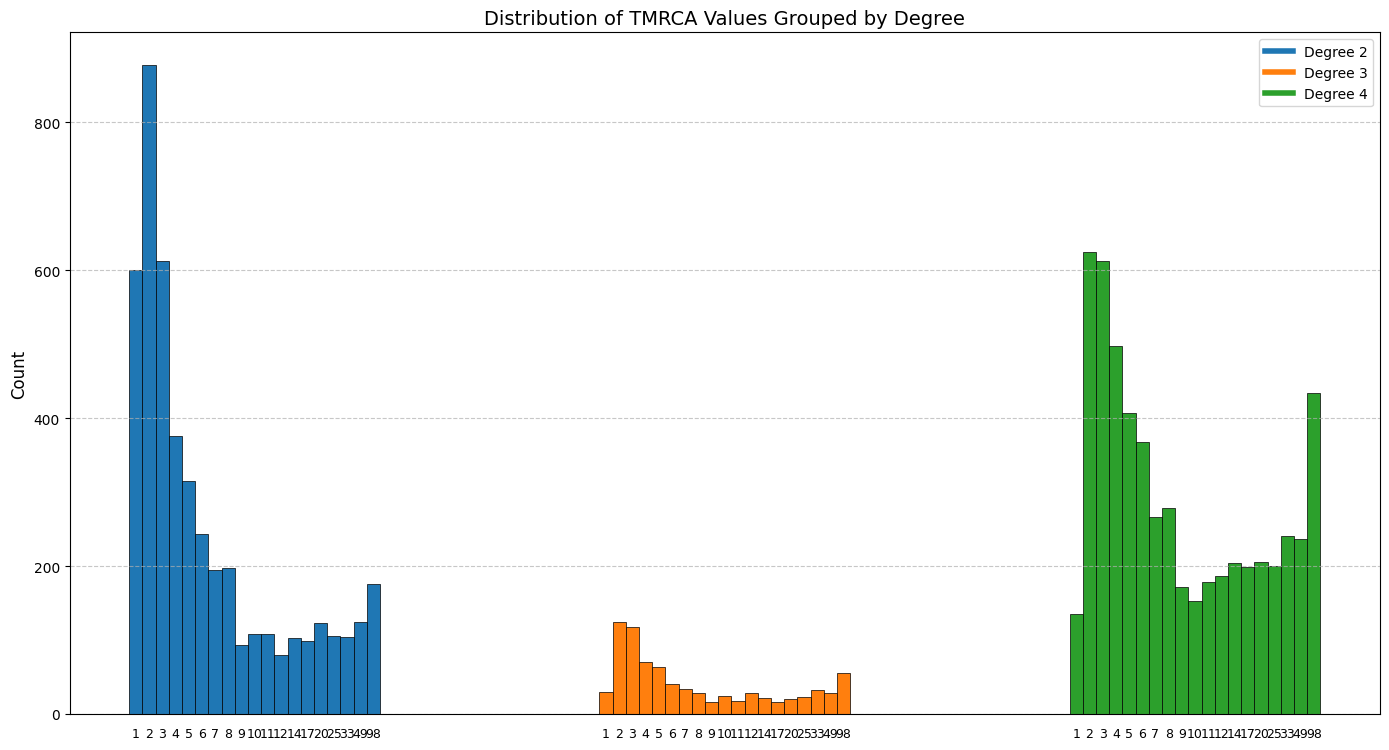

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's assume your dataframe is stored in a variable called 'df'
# First, filter for only the degrees we care about and TMRCA values <= 10
max_g = 100
df = tmrca_df
filtered_df = df[(df['degree'].isin([2, 3, 4])) & (df['tmrca'] <= max_g)]

# Group by degree and tmrca, then count occurrences
grouped = filtered_df.groupby(['degree', 'tmrca']).size().reset_index(name='count')

# Get unique degrees and TMRCA values
degrees = [2, 3, 4]  # The degrees we're interested in
tmrca_values = sorted([t for t in filtered_df['tmrca'].unique() if t <= max_g])

# Set up the plot
plt.figure(figsize=(14, 8))

# Calculate the width of each group and each bar
n_degrees = len(degrees)
n_tmrca = len(tmrca_values)
group_width = 0.8  # Width of each degree group (out of 1)
bar_width = group_width / n_tmrca  # Width of each TMRCA bar
gap_between_groups = 0.5  # Gap between degree groups

# Create a dictionary for easier data lookup
count_dict = {}
for _, row in grouped.iterrows():
    count_dict[(row['degree'], row['tmrca'])] = row['count']

# Define colors for each degree
degree_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Plot bars for each degree
for i, degree in enumerate(degrees):
    group_position = i * (1 + gap_between_groups)  # Position of this degree group
    
    # Create bar positions for this degree
    bar_positions = [group_position + j * bar_width for j in range(n_tmrca)]
    
    # Get counts for each TMRCA value for this degree
    counts = [count_dict.get((degree, tmrca), 0) for tmrca in tmrca_values]
    
    # Plot the bars for this degree (all same color)
    for j, (pos, count, tmrca) in enumerate(zip(bar_positions, counts, tmrca_values)):
        plt.bar(pos, count, bar_width, 
                color=degree_colors[i],  # Same color for all bars within a degree
                edgecolor='black', 
                linewidth=0.5)
        
        # Add TMRCA value labels directly below each bar
        plt.text(pos, -max([max(count_dict.values()) * 0.02, 5]), 
                 str(tmrca), 
                 ha='center', va='top', fontsize=9)

# Customize the plot
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of TMRCA Values Grouped by Degree', fontsize=14)

# Remove x-axis ticks and labels completely
plt.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Add a custom legend for degree colors
custom_lines = [plt.Line2D([0], [0], color=degree_colors[i], lw=4) for i in range(n_degrees)]
plt.legend(custom_lines, [f'Degree {d}' for d in degrees], loc='upper right', fontsize=10)

# Add grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Make sure the layout looks good
plt.tight_layout()

# Ensure there's space at the bottom for the TMRCA labels
plt.subplots_adjust(bottom=0.1)

plt.show()